# Scrapping

In [1]:
pip install openmeteo-requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.1/167.1 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 684.0/684.0 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.8/145.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.1/394.1 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 24.7 MB/s eta 0:00:00


In [2]:
pip install requests-cache retry-requests numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 7.4 MB/s eta 0:00:00


In [3]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

url = "https://air-quality-api.open-meteo.com/v1/air-quality"

locations = [
    {"name": "Ambon City", "latitude": -3.6958,      "longitude": 128.1833},
    {"name": "Bali", "latitude": -8.3333, "longitude": 115},
    {"name": "Balikpapan", "latitude": -1.2674, "longitude": 116.8310},
    {"name": "Bandung", "latitude": -6.9222, "longitude": 107.6069},
    {"name": "Banda Aceh", "latitude": 5.5417,  "longitude": 95.3333},
    {"name": "Bekasi", "latitude": -6.2349, "longitude": 106.9896},
    {"name": "Gorontalo", "latitude": 0.5375,  "longitude": 123.0625},
    {"name": "Jakarta", "latitude": -6.2088, "longitude": 106.8456},
    {"name": "Jayapura", "latitude": -2.5337,   "longitude": 140.7181},
    {"name": "Jogja", "latitude": -3.4292, "longitude": 119.222},
    {"name": "Kendari", "latitude": -3.9778,   "longitude": 122.5151},
    {"name": "Kupang", "latitude": -10.1708,    "longitude": 123.6069},
    {"name": "Makassar", "latitude": 0.9039, "longitude": 122.7586},
    {"name": "Manado", "latitude": 1.4822,      "longitude": 124.8489},
    {"name": "Mataram", "latitude": -8.5833,   "longitude": 116.1167},
    {"name": "Medan", "latitude": 3.5833, "longitude": 98.6667},
    {"name": "Merauke", "latitude": -8.4996,     "longitude": 140.4061},
    {"name": "Padang", "latitude": -0.9492, "longitude": 100.3543},
    {"name": "Palangkaraya", "latitude": -2.2083,"longitude": 113.9165},
    {"name": "Palembang", "latitude": -2.9167, "longitude": 104.7458},
    {"name": "Palu", "latitude": -0.9083,       "longitude": 119.8708},
    {"name": "Pekanbaru", "latitude": 0.5167, "longitude": 101.4417},
    {"name": "Pontianak", "latitude": -0.0319,   "longitude": 109.325},
    {"name": "Samarinda", "latitude": -0.4917,   "longitude": 117.1458},
    {"name": "Semarang", "latitude": -6.9931, "longitude": 110.4208},
    {"name": "Surabaya", "latitude": -7.2575, "longitude": 112.7521},
    {"name": "Tarakan", "latitude": 3.3133,      "longitude": 117.5915},
    {"name": "Tegal", "latitude": -6.8694, "longitude": 109.1402},
    {"name": "Ternate", "latitude": 0.7906,      "longitude": 127.3842},
    {"name": "Wonosobo", "latitude": -7.3589, "longitude": 109.9031}
]

all_hourly_dataframes = []

for location in locations:
    print(f"Fetching data for {location['name']}...")
    params = {
        "latitude": location["latitude"],
        "longitude": location["longitude"],
        "hourly": ["us_aqi", "us_aqi_pm2_5", "us_aqi_nitrogen_dioxide", "us_aqi_carbon_monoxide", "us_aqi_ozone", "us_aqi_pm10", "us_aqi_sulphur_dioxide"],
        "timezone": "auto",
        "start_date": "2025-09-10",
        "end_date": "2025-10-10",
    }
    responses = openmeteo.weather_api(url, params=params)

    response = responses[0]
    print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
    print(f"Elevation: {response.Elevation()} m asl")
    print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
    print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

    hourly = response.Hourly()
    hourly_us_aqi = hourly.Variables(0).ValuesAsNumpy()
    hourly_us_aqi_pm2_5 = hourly.Variables(1).ValuesAsNumpy()
    hourly_us_aqi_nitrogen_dioxide = hourly.Variables(2).ValuesAsNumpy()
    hourly_us_aqi_carbon_monoxide = hourly.Variables(3).ValuesAsNumpy()
    hourly_us_aqi_ozone = hourly.Variables(4).ValuesAsNumpy()
    hourly_us_aqi_pm10 = hourly.Variables(5).ValuesAsNumpy()
    hourly_us_aqi_sulphur_dioxide = hourly.Variables(6).ValuesAsNumpy()

    hourly_data = {
        "date": pd.date_range(
            start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
            end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
            freq = pd.Timedelta(seconds = hourly.Interval()),
            inclusive = "left"
        )
    }

    hourly_data["us_aqi"] = hourly_us_aqi
    hourly_data["us_aqi_pm2_5"] = hourly_us_aqi_pm2_5
    hourly_data["us_aqi_nitrogen_dioxide"] = hourly_us_aqi_nitrogen_dioxide
    hourly_data["us_aqi_carbon_monoxide"] = hourly_us_aqi_carbon_monoxide
    hourly_data["us_aqi_ozone"] = hourly_us_aqi_ozone
    hourly_data["us_aqi_pm10"] = hourly_us_aqi_pm10
    hourly_data["us_aqi_sulphur_dioxide"] = hourly_us_aqi_sulphur_dioxide

    hourly_dataframe_single_location = pd.DataFrame(data = hourly_data)
    hourly_dataframe_single_location['location_name'] = location['name']
    all_hourly_dataframes.append(hourly_dataframe_single_location)

overall_hourly_dataframe = pd.concat(all_hourly_dataframes, ignore_index=True)
print("\nOverall Hourly Data for all locations:\n")
display(overall_hourly_dataframe.head())
display(overall_hourly_dataframe.tail())


Fetching data for Ambon City...
Coordinates: -3.6999969482421875°N 128.20001220703125°E
Elevation: 7.0 m asl
Timezone: b'Asia/Jayapura'b'GMT+9'
Timezone difference to GMT+0: 32400s
Fetching data for Bali...
Coordinates: -8.299995422363281°N 115.0°E
Elevation: 616.0 m asl
Timezone: b'Asia/Makassar'b'GMT+8'
Timezone difference to GMT+0: 28800s
Fetching data for Balikpapan...
Coordinates: -1.2999954223632812°N 116.80001831054688°E
Elevation: 50.0 m asl
Timezone: b'Asia/Makassar'b'GMT+8'
Timezone difference to GMT+0: 28800s
Fetching data for Bandung...
Coordinates: -6.900001525878906°N 107.60000610351562°E
Elevation: 707.0 m asl
Timezone: b'Asia/Jakarta'b'GMT+7'
Timezone difference to GMT+0: 25200s
Fetching data for Banda Aceh...
Coordinates: 5.5°N 95.30001831054688°E
Elevation: 5.0 m asl
Timezone: b'Asia/Jakarta'b'GMT+7'
Timezone difference to GMT+0: 25200s
Fetching data for Bekasi...
Coordinates: -6.1999969482421875°N 107.0°E
Elevation: 19.0 m asl
Timezone: b'Asia/Jakarta'b'GMT+7'
Timezo

,date,us_aqi,us_aqi_pm2_5,us_aqi_nitrogen_dioxide,us_aqi_carbon_monoxide,us_aqi_ozone,us_aqi_pm10,us_aqi_sulphur_dioxide,location_name
0,2025-09-09 15:00:00+00:00,15.596010,11.458334,0.591017,5.560386,15.596010,3.087121,0.218103,Ambon City
1,2025-09-09 16:00:00+00:00,15.132191,11.354167,0.492514,6.044686,15.132191,3.075758,0.218103,Ambon City
2,2025-09-09 17:00:00+00:00,14.726344,11.267361,0.443262,6.349034,14.726344,3.071970,0.163577,Ambon City
3,2025-09-09 18:00:00+00:00,14.436457,11.180555,0.344760,6.411836,14.436457,3.068182,0.163577,Ambon City
4,2025-09-09 19:00:00+00:00,14.320501,11.076390,0.295508,6.138889,14.320501,3.064394,0.163577,Ambon City


,date,us_aqi,us_aqi_pm2_5,us_aqi_nitrogen_dioxide,us_aqi_carbon_monoxide,us_aqi_ozone,us_aqi_pm10,us_aqi_sulphur_dioxide,location_name
22315,2025-10-10 12:00:00+00:00,156.024124,156.024124,7.978724,2.729469,85.416664,56.758331,3.162487,Wonosobo
22316,2025-10-10 13:00:00+00:00,155.186401,155.186401,8.224981,3.483092,75.000000,55.933338,2.998909,Wonosobo
22317,2025-10-10 14:00:00+00:00,153.921051,153.921051,8.618992,4.439614,61.819725,54.695839,2.726282,Wonosobo
22318,2025-10-10 15:00:00+00:00,151.925430,151.925430,9.013002,5.577294,48.875229,52.766670,2.399128,Wonosobo
22319,2025-10-10 16:00:00+00:00,149.447891,149.447891,9.259259,6.822464,43.773190,50.785416,1.853872,Wonosobo


In [4]:
import numpy as np

air_quality_data = pd.DataFrame({
    'Date': overall_hourly_dataframe['date'],
    'City': overall_hourly_dataframe['location_name'],
    'CO': overall_hourly_dataframe['us_aqi_carbon_monoxide'],
    'CO2': np.nan,
    'NO2': overall_hourly_dataframe['us_aqi_nitrogen_dioxide'],
    'SO2': overall_hourly_dataframe['us_aqi_sulphur_dioxide'],
    'O3': overall_hourly_dataframe['us_aqi_ozone'],
    'PM2.5': overall_hourly_dataframe['us_aqi_pm2_5'],
    'PM10': overall_hourly_dataframe['us_aqi_pm10'],
    'AQI': overall_hourly_dataframe['us_aqi']
})

print("Restructured Air Quality Data:")
display(air_quality_data.head())
display(air_quality_data.tail())

Restructured Air Quality Data:


,Date,City,CO,CO2,NO2,SO2,O3,PM2.5,PM10,AQI
0,2025-09-09 15:00:00+00:00,Ambon City,5.560386,NaN,0.591017,0.218103,15.596010,11.458334,3.087121,15.596010
1,2025-09-09 16:00:00+00:00,Ambon City,6.044686,NaN,0.492514,0.218103,15.132191,11.354167,3.075758,15.132191
2,2025-09-09 17:00:00+00:00,Ambon City,6.349034,NaN,0.443262,0.163577,14.726344,11.267361,3.071970,14.726344
3,2025-09-09 18:00:00+00:00,Ambon City,6.411836,NaN,0.344760,0.163577,14.436457,11.180555,3.068182,14.436457
4,2025-09-09 19:00:00+00:00,Ambon City,6.138889,NaN,0.295508,0.163577,14.320501,11.076390,3.064394,14.320501


,Date,City,CO,CO2,NO2,SO2,O3,PM2.5,PM10,AQI
22315,2025-10-10 12:00:00+00:00,Wonosobo,2.729469,NaN,7.978724,3.162487,85.416664,156.024124,56.758331,156.024124
22316,2025-10-10 13:00:00+00:00,Wonosobo,3.483092,NaN,8.224981,2.998909,75.000000,155.186401,55.933338,155.186401
22317,2025-10-10 14:00:00+00:00,Wonosobo,4.439614,NaN,8.618992,2.726282,61.819725,153.921051,54.695839,153.921051
22318,2025-10-10 15:00:00+00:00,Wonosobo,5.577294,NaN,9.013002,2.399128,48.875229,151.925430,52.766670,151.925430
22319,2025-10-10 16:00:00+00:00,Wonosobo,6.822464,NaN,9.259259,1.853872,43.773190,149.447891,50.785416,149.447891


In [5]:
air_quality_data.to_csv('air_quality_data(fetch).csv', index=False)
print("Dataset telah berhasil disimpan")

Dataset telah berhasil disimpan


# Combining Data

In [6]:
import pandas as pd

data1 = "https://github.com/KhalPrawira/Big-Data_Assignment/raw/refs/heads/main/Dataset/Air_Quality.csv"

data2 = "/content/air_quality_data(fetch).csv"

df1 = pd.read_csv(data1)

df2 = pd.read_csv(data2)

combined_df = pd.concat([df1, df2], ignore_index=True)

print("Dataframe pertama (df1) head:")
print(df1.head())
print("\nDataframe kedua (df2) head:")
print(df2.head())
print("\nGabungan Dataframe (combined_df) head:")
print(combined_df.head())

print(f"\nJumlah baris df1: {len(df1)}")
print(f"Jumlah baris df2: {len(df2)}")
print(f"Jumlah baris gabungan: {len(combined_df)}")

Dataframe pertama (df1) head:
                        Date      City     CO  CO2   NO2  SO2    O3  PM2.5  \
0  2024-01-01 00:00:00+00:00  Brasilia  323.0  NaN  23.8  2.8  42.0   12.0   
1  2024-01-01 01:00:00+00:00  Brasilia  318.0  NaN  21.9  2.7  40.0   12.5   
2  2024-01-01 02:00:00+00:00  Brasilia  309.0  NaN  19.2  2.6  39.0   12.1   
3  2024-01-01 03:00:00+00:00  Brasilia  295.0  NaN  16.3  2.4  38.0   11.4   
4  2024-01-01 04:00:00+00:00  Brasilia  270.0  NaN  13.0  2.1  40.0   10.2   

   PM10        AQI  
0  17.1  16.800000  
1  17.9  16.000000  
2  17.3  15.599999  
3  16.2  15.200000  
4  14.6  16.000000  

Dataframe kedua (df2) head:
                        Date        City        CO  CO2       NO2       SO2  \
0  2025-09-09 15:00:00+00:00  Ambon City  5.560386  NaN  0.591017  0.218103   
1  2025-09-09 16:00:00+00:00  Ambon City  6.044686  NaN  0.492514  0.218103   
2  2025-09-09 17:00:00+00:00  Ambon City  6.349034  NaN  0.443262  0.163577   
3  2025-09-09 18:00:00+00:00  

In [7]:
output_filename = "combined_air_quality_data.csv"
combined_df.to_csv(output_filename, index=False)
print(f"Dataset gabungan telah berhasil disimpan ke '{output_filename}'")

Dataset gabungan telah berhasil disimpan ke 'combined_air_quality_data.csv'


# Load and Explore

In [8]:
import pandas as pd
import numpy as np

df = "/content/combined_air_quality_data.csv"
df = pd.read_csv(df)

print("jumlah baris dan kolom: ", df.shape)
display(df.head())

jumlah baris dan kolom:  (75024, 10)


,Date,City,CO,CO2,NO2,SO2,O3,PM2.5,PM10,AQI
0,2024-01-01 00:00:00+00:00,Brasilia,323.0,NaN,23.8,2.8,42.0,12.0,17.1,16.800000
1,2024-01-01 01:00:00+00:00,Brasilia,318.0,NaN,21.9,2.7,40.0,12.5,17.9,16.000000
2,2024-01-01 02:00:00+00:00,Brasilia,309.0,NaN,19.2,2.6,39.0,12.1,17.3,15.599999
3,2024-01-01 03:00:00+00:00,Brasilia,295.0,NaN,16.3,2.4,38.0,11.4,16.2,15.200000
4,2024-01-01 04:00:00+00:00,Brasilia,270.0,NaN,13.0,2.1,40.0,10.2,14.6,16.000000


In [9]:
df.info()

print("\nJumlah missing value di setiap kolom:")
print(df.isnull().sum())

duplicates = df.duplicated().sum()
print("\nJumlah data duplikat:", duplicates)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75024 entries, 0 to 75023
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    75024 non-null  object 
 1   City    75024 non-null  object 
 2   CO      75024 non-null  float64
 3   CO2     9648 non-null   float64
 4   NO2     75024 non-null  float64
 5   SO2     75024 non-null  float64
 6   O3      75024 non-null  float64
 7   PM2.5   75024 non-null  float64
 8   PM10    75024 non-null  float64
 9   AQI     75024 non-null  float64
dtypes: float64(8), object(2)
memory usage: 5.7+ MB

Jumlah missing value di setiap kolom:
Date         0
City         0
CO           0
CO2      65376
NO2          0
SO2          0
O3           0
PM2.5        0
PM10         0
AQI          0
dtype: int64

Jumlah data duplikat: 0


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("Set2")

print("Statistik deskriptif data numerik:\n")
display(df.describe())

Statistik deskriptif data numerik:



,CO,CO2,NO2,SO2,O3,PM2.5,PM10,AQI
count,75024.000000,9648.000000,75024.000000,75024.000000,75024.000000,75024.000000,75024.000000,75024.000000
mean,183.149297,462.348259,18.916526,10.164882,52.019026,32.879190,31.583659,50.179539
std,176.712136,33.769009,19.256980,15.479247,39.653526,36.311065,42.426165,36.961395
min,0.797102,434.000000,0.000000,0.000000,0.000000,0.100000,0.100000,4.450000
25%,9.514192,445.000000,4.000000,1.472192,23.000000,9.000000,10.000000,24.800000
50%,168.000000,453.000000,12.800000,3.900000,43.000000,19.600000,16.922349,37.600000
75%,257.000000,467.000000,28.000000,12.700000,70.000000,45.368922,34.100000,63.023126
max,2045.000000,884.000000,165.900000,239.700000,349.000000,190.750000,543.900000,241.192260


# Data Cleaning

In [11]:
df.drop('CO2', axis=1, inplace=True)
print("Kolom 'CO2' telah dihapus.")
df.info()

print("\nJumlah missing value di setiap kolom:")
print(df.isnull().sum())

Kolom 'CO2' telah dihapus.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75024 entries, 0 to 75023
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    75024 non-null  object 
 1   City    75024 non-null  object 
 2   CO      75024 non-null  float64
 3   NO2     75024 non-null  float64
 4   SO2     75024 non-null  float64
 5   O3      75024 non-null  float64
 6   PM2.5   75024 non-null  float64
 7   PM10    75024 non-null  float64
 8   AQI     75024 non-null  float64
dtypes: float64(7), object(2)
memory usage: 5.2+ MB

Jumlah missing value di setiap kolom:
Date     0
City     0
CO       0
NO2      0
SO2      0
O3       0
PM2.5    0
PM10     0
AQI      0
dtype: int64


# Checking Outlier

In [12]:
print("\nMendeteksi Outlier menggunakan IQR:")

numerical_cols = df.select_dtypes(include=np.number).columns

outlier_count = 0
total_data_points = 0

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Mendeteksi outlier
    col_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    num_outliers = len(col_outliers)
    outlier_count += num_outliers
    total_data_points += len(df[col])

    if num_outliers > 0:
        print(f"  Kolom '{col}': {num_outliers} outlier terdeteksi ({round((num_outliers / len(df[col])) * 100, 2)}% dari total data kolom ini)")
    else:
        print(f"  Kolom '{col}': Tidak ada outlier terdeteksi.")

print(f"\nTotal outlier terdeteksi di seluruh kolom numerik: {outlier_count} dari {total_data_points} data poin.")
if total_data_points > 0:
    print(f"Persentase total outlier: {round((outlier_count / total_data_points) * 100, 2)}%")
else:
    print("Tidak ada data poin untuk dianalisis.")


Mendeteksi Outlier menggunakan IQR:
  Kolom 'CO': 1969 outlier terdeteksi (2.62% dari total data kolom ini)
  Kolom 'NO2': 2680 outlier terdeteksi (3.57% dari total data kolom ini)
  Kolom 'SO2': 6397 outlier terdeteksi (8.53% dari total data kolom ini)
  Kolom 'O3': 2540 outlier terdeteksi (3.39% dari total data kolom ini)
  Kolom 'PM2.5': 4314 outlier terdeteksi (5.75% dari total data kolom ini)
  Kolom 'PM10': 7778 outlier terdeteksi (10.37% dari total data kolom ini)
  Kolom 'AQI': 4771 outlier terdeteksi (6.36% dari total data kolom ini)

Total outlier terdeteksi di seluruh kolom numerik: 30449 dari 525168 data poin.
Persentase total outlier: 5.8%


Menampilkan outlier menggunakan Box Plot:


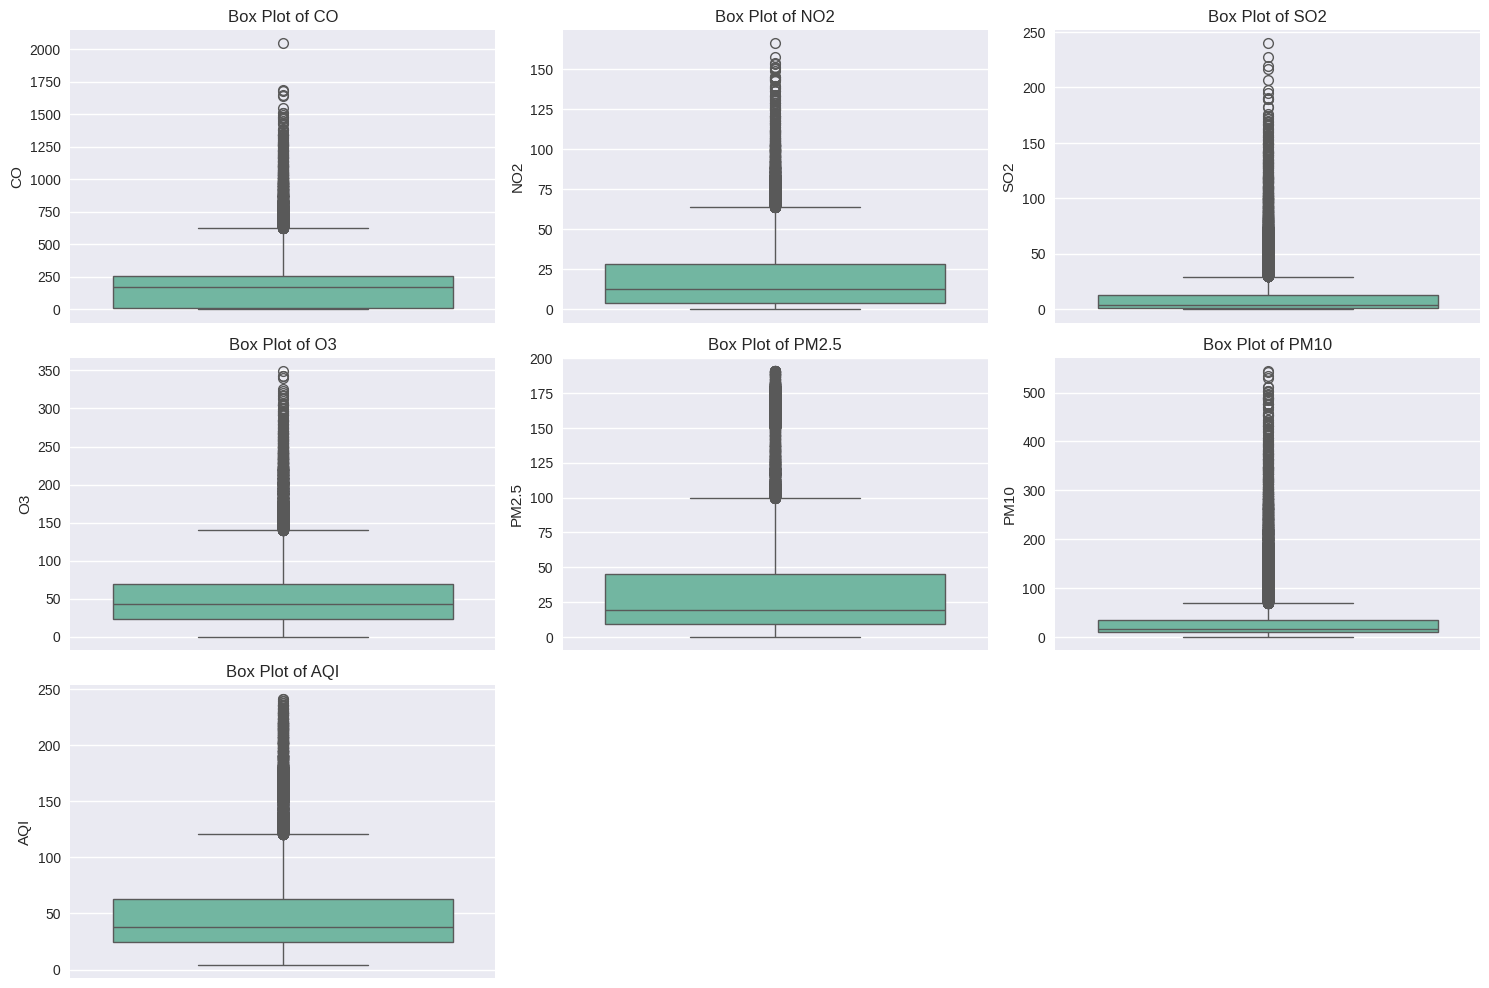

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Menampilkan outlier menggunakan Box Plot:")

numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

# EDA

In [14]:
print("Statistik deskriptif data numerik:\n")
display(df.describe())

Statistik deskriptif data numerik:



,CO,NO2,SO2,O3,PM2.5,PM10,AQI
count,75024.000000,75024.000000,75024.000000,75024.000000,75024.000000,75024.000000,75024.000000
mean,183.149297,18.916526,10.164882,52.019026,32.879190,31.583659,50.179539
std,176.712136,19.256980,15.479247,39.653526,36.311065,42.426165,36.961395
min,0.797102,0.000000,0.000000,0.000000,0.100000,0.100000,4.450000
25%,9.514192,4.000000,1.472192,23.000000,9.000000,10.000000,24.800000
50%,168.000000,12.800000,3.900000,43.000000,19.600000,16.922349,37.600000
75%,257.000000,28.000000,12.700000,70.000000,45.368922,34.100000,63.023126
max,2045.000000,165.900000,239.700000,349.000000,190.750000,543.900000,241.192260


Membuat heatmap korelasi:


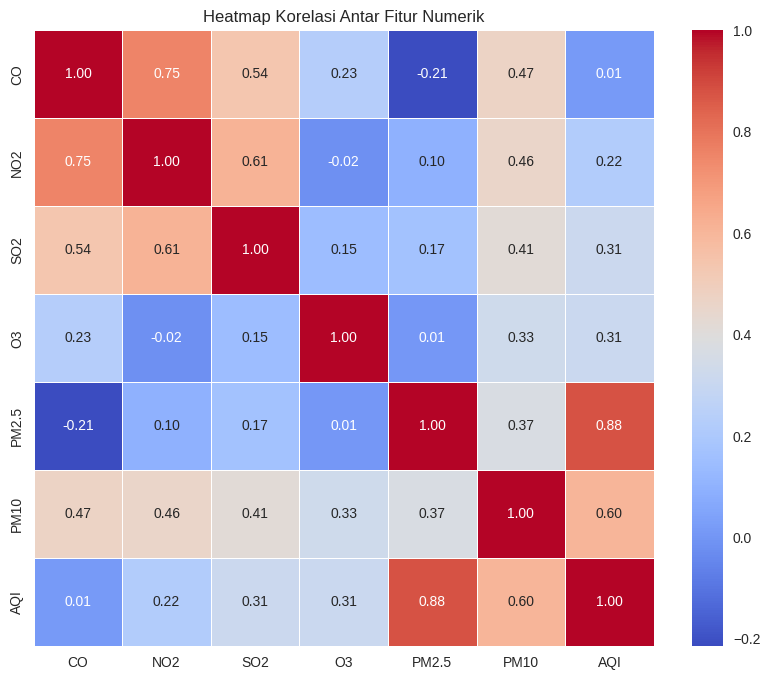

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Membuat heatmap korelasi:")

numerical_cols = df.select_dtypes(include=np.number).columns

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap Korelasi Antar Fitur Numerik')
plt.show()

1. Seberapa kuat korelasi (Measurable: koefisien korelasi Pearson) antara kadar $PM_{2.5}$ dengan skor $AQI$ di kota Brasilia selama 6 bulan pertama tahun 2024?

Koefisien Korelasi Pearson (PM2.5 vs AQI) di Brasilia (H1 2024): -0.12264894082048672


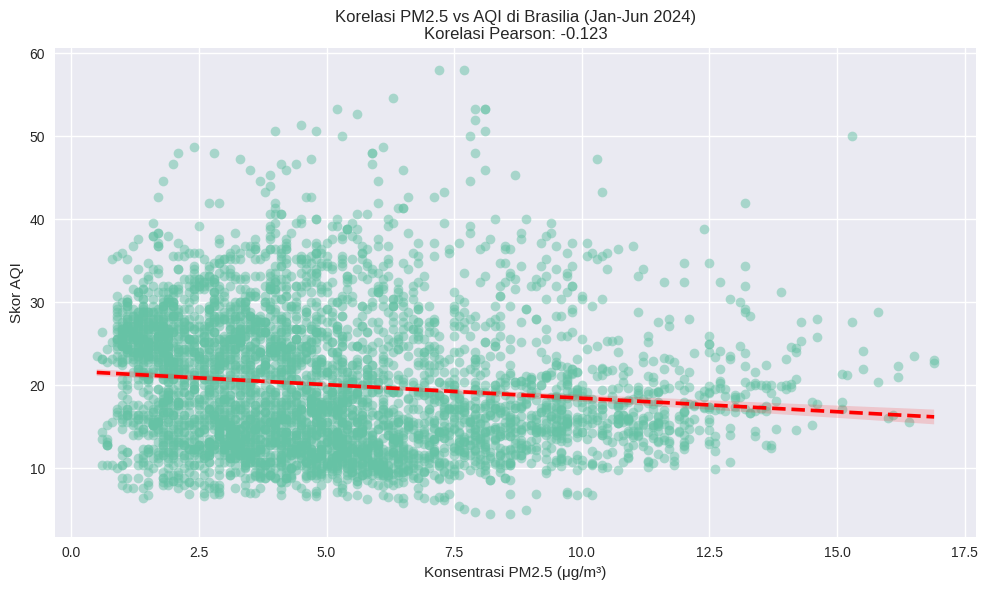

In [16]:
df['Date'] = pd.to_datetime(df['Date'])

df_q1 = df[
    (df['City'] == 'Brasilia') &
    (df['Date'] >= '2024-01-01') &
    (df['Date'] < '2024-07-01')
].copy()

if not df_q1.empty:
    pearson_corr = df_q1[['PM2.5', 'AQI']].corr().loc['PM2.5', 'AQI']
    print(f"Koefisien Korelasi Pearson (PM2.5 vs AQI) di Brasilia (H1 2024): {pearson_corr}")

    plt.figure(figsize=(10, 6))
    sns.regplot(data=df_q1, x='PM2.5', y='AQI', line_kws={"color": "red", "linestyle": "--"}, scatter_kws={'alpha': 0.5})
    plt.title(f'Korelasi PM2.5 vs AQI di Brasilia (Jan-Jun 2024)\nKorelasi Pearson: {pearson_corr:.3f}')
    plt.xlabel('Konsentrasi PM2.5 (μg/m³)')
    plt.ylabel('Skor AQI')
    plt.tight_layout()
    plt.show()

else:
    print("Tidak ada data untuk Q1 (Brasilia, H1 2024).")

2. Apakah terdapat perbedaan signifikan (Measurable: selisih rata-rata atau uji statistik) pada rata-rata $AQI$ antara hari kerja (Senin-Jumat) dan akhir pekan (Sabtu-Minggu) di kota Brasilia selama tahun 2024?

Rata-rata AQI berdasarkan Tipe Hari di Brasilia (2024):
       DayType        AQI
0  Akhir Pekan  24.726623
1   Hari Kerja  24.758383


/tmp/ipython-input-3756443035.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=avg_aqi_daytype, x='DayType', y='AQI', order=['Hari Kerja', 'Akhir Pekan'], palette=['#2ca02c', '#d62728'])


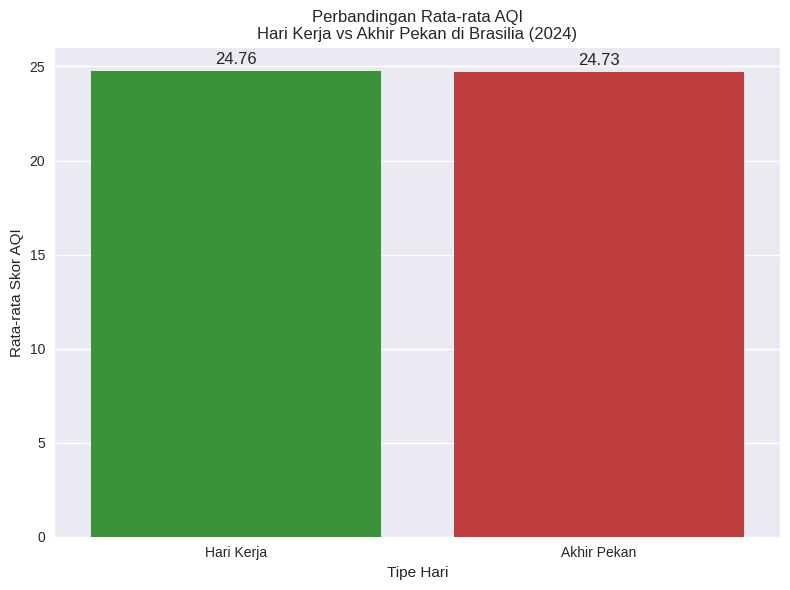

In [17]:
df_q5 = df[
    (df['City'] == 'Brasilia') &
    (df['Date'] >= '2024-01-01') &
    (df['Date'] < '2025-01-01')
].copy()

if not df_q5.empty and not df_q5['AQI'].isnull().all():
    df_q5['DayOfWeek'] = df_q5['Date'].dt.dayofweek
    df_q5['DayType'] = df_q5['DayOfWeek'].apply(lambda x: 'Akhir Pekan' if x >= 5 else 'Hari Kerja')

    avg_aqi_daytype = df_q5.groupby('DayType')['AQI'].mean().reset_index()
    print("Rata-rata AQI berdasarkan Tipe Hari di Brasilia (2024):")
    print(avg_aqi_daytype)

    plt.figure(figsize=(8, 6))
    bars = sns.barplot(data=avg_aqi_daytype, x='DayType', y='AQI', order=['Hari Kerja', 'Akhir Pekan'], palette=['#2ca02c', '#d62728'])

    for bar in bars.patches:
        bars.annotate(format(bar.get_height(), '.2f'),
                       (bar.get_x() + bar.get_width() / 2,
                        bar.get_height()), ha='center', va='center',
                       size=12, xytext=(0, 8),
                       textcoords='offset points')

    plt.title('Perbandingan Rata-rata AQI\nHari Kerja vs Akhir Pekan di Brasilia (2024)')
    plt.xlabel('Tipe Hari')
    plt.ylabel('Rata-rata Skor AQI')
    plt.tight_layout()
    plt.show()

else:
    print("Tidak ada data untuk Q5 (Brasilia, 2024).")

3. Pada jam berapa rata-rata konsentrasi $NO_2$ mencapai puncaknya (Measurable: nilai $\mu g/m^3$ maksimum rata-rata) di kota Wonosobo selama bulan Oktober 2025?

Rata-rata NO2 per Jam di Wonosobo (Okt 2025):
    Jam        NO2
0     0   7.235028
1     1   5.447202
2     2   2.994484
3     3   1.196809
4     4   0.679669
5     5   0.822498
6     6   1.098306
7     7   0.871749
8     8   0.783097
9     9   2.206462
10   10   6.368203
11   11  12.051812
12   12  16.952325
13   13  19.419819
14   14  22.788613
15   15  24.916273
16   16  24.704491
17   17  24.784389
18   18  23.016812
19   19  21.621356
20   20  20.089090
21   21  18.179231
22   22  15.678355
23   23  12.783469
Puncak NO2 terjadi pada: Jam 15.0 dengan rata-rata 24.92 μg/m³


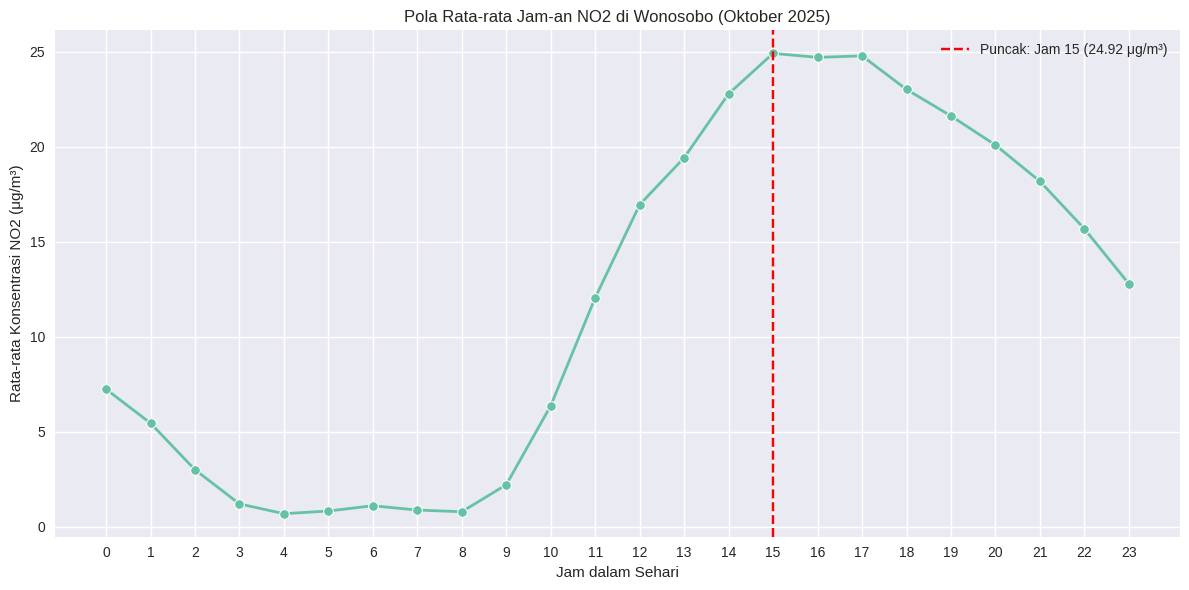

In [18]:
df_q4 = df[
    (df['City'] == 'Wonosobo') &
    (df['Date'] >= '2025-10-01') &
    (df['Date'] < '2025-11-01')
].copy()

if not df_q4.empty and not df_q4['NO2'].isnull().all():
    df_q4['Jam'] = df_q4['Date'].dt.hour

    avg_no2_hourly = df_q4.groupby('Jam')['NO2'].mean().reset_index()
    print("Rata-rata NO2 per Jam di Wonosobo (Okt 2025):")
    print(avg_no2_hourly)

    peak_hour = avg_no2_hourly.loc[avg_no2_hourly['NO2'].idxmax()]
    print(f"Puncak NO2 terjadi pada: Jam {peak_hour['Jam']} dengan rata-rata {peak_hour['NO2']:.2f} μg/m³")

    plt.figure(figsize=(12, 6))
    ax = sns.lineplot(data=avg_no2_hourly, x='Jam', y='NO2', marker='o', lw=2)

    plt.axvline(x=peak_hour['Jam'], color='red', linestyle='--', label=f"Puncak: Jam {int(peak_hour['Jam'])} ({peak_hour['NO2']:.2f} μg/m³)")

    plt.title('Pola Rata-rata Jam-an NO2 di Wonosobo (Oktober 2025)')
    plt.xlabel('Jam dalam Sehari')
    plt.ylabel('Rata-rata Konsentrasi NO2 (μg/m³)')
    plt.xticks(np.arange(0, 24, 1))
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("Tidak ada data untuk Q4 (Wonosobo, Okt 2025).")

4. Selama tahun 2025, bagaimana tren rata-rata AQI bulanan di Jakarta, dan polutan mana (PM2.5, NO2, O3, SO2, PM10) yang paling banyak berkontribusi terhadap kenaikan AQI pada bulan-bulan puncak?

Korelasi tiap polutan dengan AQI di Jakarta (2025):
AQI      1.000000
O3       0.694388
PM2.5    0.653973
PM10     0.652392
SO2      0.191097
NO2      0.176518
Name: AQI, dtype: float64


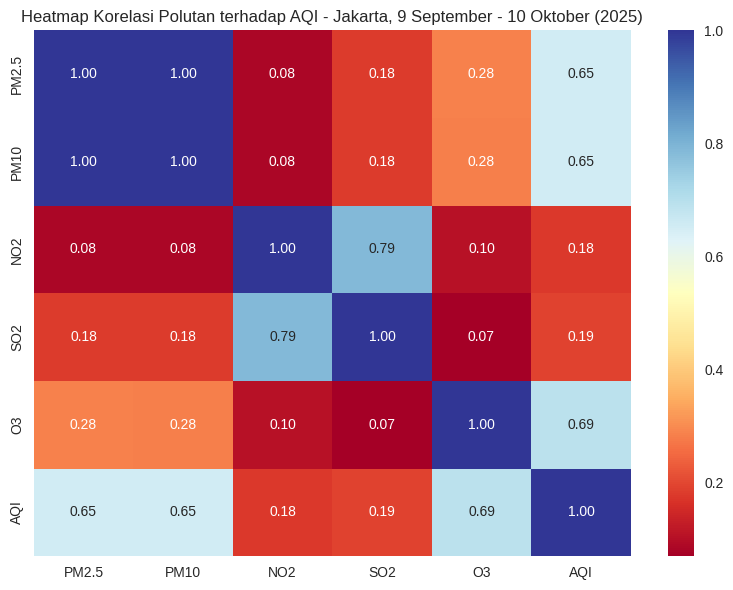

In [19]:
df_jakarta = df[
    (df['City'] == 'Jakarta') &
    (df['Date'].dt.year == 2025)
].copy()

if not df_jakarta.empty:
    pollutant_cols = ['PM2.5', 'PM10', 'NO2', 'SO2', 'O3', 'AQI']
    df_corr = df_jakarta[pollutant_cols].corr()

    print("Korelasi tiap polutan dengan AQI di Jakarta (2025):")
    print(df_corr['AQI'].sort_values(ascending=False))

    plt.figure(figsize=(8,6))
    sns.heatmap(df_corr, annot=True, cmap='RdYlBu', fmt=".2f")
    plt.title('Heatmap Korelasi Polutan terhadap AQI - Jakarta, 9 September - 10 Oktober (2025)')
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data untuk Jakarta (2025).")

5. Selama periode 2025-09-10 sampai 2025-10-10 (periode scraping), berapa persen kejadian AQI ≥ 151 (Unhealthy atau lebih buruk) di seluruh dataset Indonesia yang memiliki PM2.5 sebagai polutan dominan

Total kejadian AQI >= 151: 3012
Jumlah kejadian AQI>=151 yang PM2.5-dominan: 2428 (80.61%)


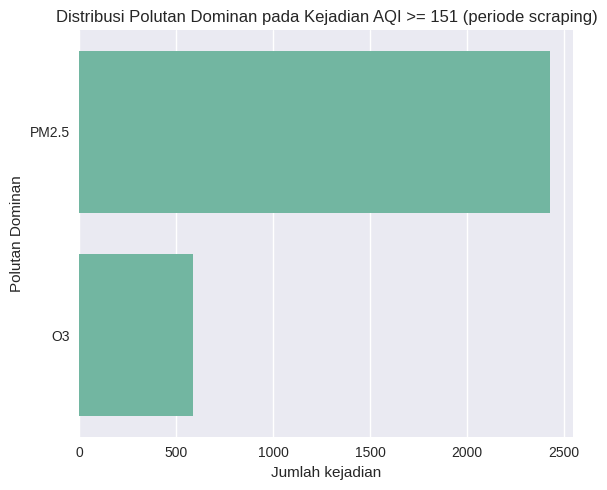

In [20]:
start, end = '2025-09-10', '2025-10-10'
mask = (df['Date'] >= start) & (df['Date'] <= end)
subset = df.loc[mask].copy()

if subset.empty:
    print("Tidak ada data pada periode yang diminta.")
else:
    bad = subset[subset['AQI'] >= 151].copy()
    total_bad = len(bad)
    print("Total kejadian AQI >= 151:", total_bad)

    if total_bad == 0:
        print("Tidak ada kejadian AQI >= 151 pada periode ini.")
    else:
        pol_cols = ['PM2.5','NO2','O3','SO2','PM10']
        bad['dominant'] = bad[pol_cols].idxmax(axis=1)
        pm25_count = (bad['dominant'] == 'PM2.5').sum()
        percent_pm25 = 100 * pm25_count / total_bad
        print(f"Jumlah kejadian AQI>=151 yang PM2.5-dominan: {pm25_count} ({percent_pm25:.2f}%)")

        plt.figure(figsize=(6,5))
        sns.countplot(data=bad, y='dominant', order=bad['dominant'].value_counts().index)
        plt.title('Distribusi Polutan Dominan pada Kejadian AQI >= 151 (periode scraping)')
        plt.xlabel('Jumlah kejadian')
        plt.ylabel('Polutan Dominan')
        plt.tight_layout()
        plt.show()

6. Bagaimana pola rata-rata PM10 berubah dari pagi hingga malam hari di kota Surabaya selama seminggu pertama bulan Oktober 2025?

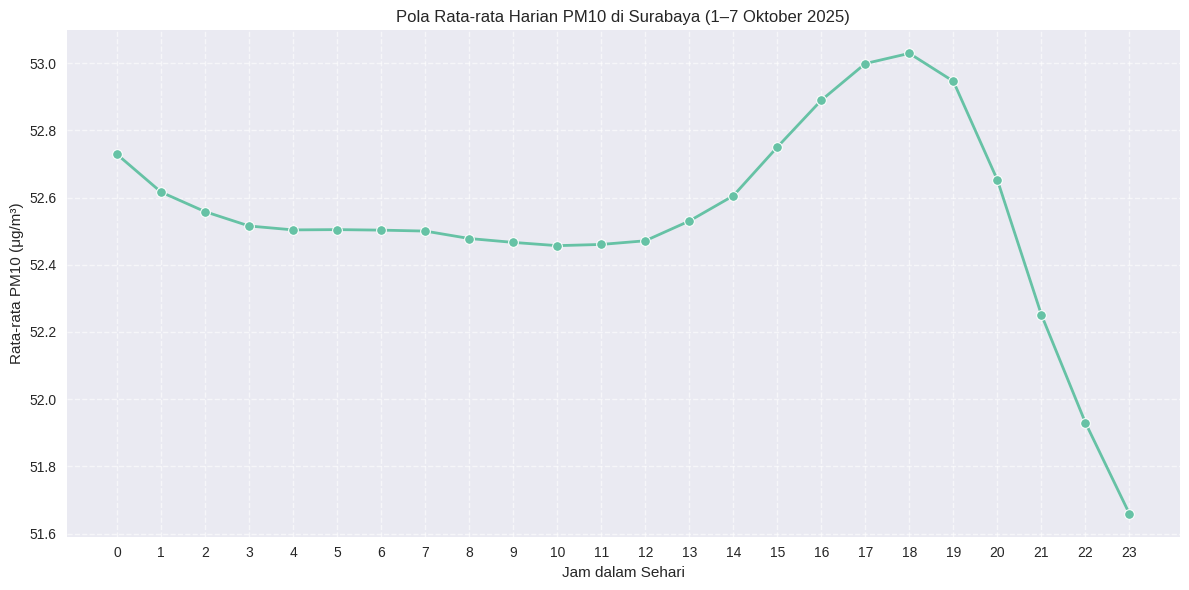

Puncak PM10 terjadi pada jam 18 dengan rata-rata 53.03 μg/m³


In [42]:
df_q7 = df[
    (df['City'] == 'Surabaya') &
    (df['Date'] >= '2025-10-01') &
    (df['Date'] < '2025-10-07')
].copy()

if not df_q7.empty and not df_q7['PM10'].isnull().all():
    df_q7['Jam'] = df_q7['Date'].dt.hour
    avg_pm10_hourly = df_q7.groupby('Jam')['PM10'].mean().reset_index()

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=avg_pm10_hourly, x='Jam', y='PM10', marker='o', lw=2)
    plt.title('Pola Rata-rata Harian PM10 di Surabaya (1–7 Oktober 2025)')
    plt.xlabel('Jam dalam Sehari')
    plt.ylabel('Rata-rata PM10 (μg/m³)')
    plt.xticks(range(0, 24, 1))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    peak_hour = avg_pm10_hourly.loc[avg_pm10_hourly['PM10'].idxmax()]
    print(f"Puncak PM10 terjadi pada jam {int(peak_hour['Jam'])} dengan rata-rata {peak_hour['PM10']:.2f} μg/m³")
else:
    print("Tidak ada data untuk Surabaya (1–7 Oktober 2025).")

# Preparation

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

X = df[['NO2','SO2','O3','PM2.5','PM10']]
y = df['AQI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data train:", X_train.shape)
print("Data test :", X_test.shape)

Data train: (60019, 5)
Data test : (15005, 5)


# Modeling

* Linear Regression

📈 Linear Regression Results:
Mean Absolute Error (MAE): 7.0
Mean Squared Error (MSE): 118.95
Root Mean Squared Error (RMSE): 10.91
R² Score: 0.911

Cross-validation R² Scores: [np.float64(0.911), np.float64(0.914), np.float64(0.918), np.float64(0.912), np.float64(0.913)]
Mean CV R² Score: 0.913
Std Dev CV R² Score: 0.002


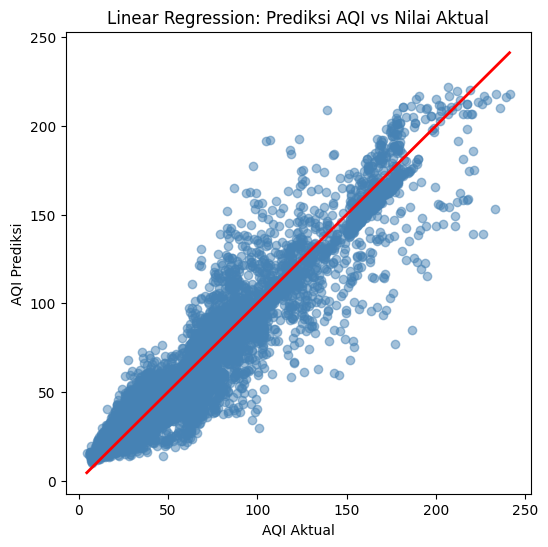

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

print("📈 Linear Regression Results:")
print("Mean Absolute Error (MAE):", round(mae_lr, 2))
print("Mean Squared Error (MSE):", round(mse_lr, 2))
print("Root Mean Squared Error (RMSE):", round(rmse_lr, 2))
print("R² Score:", round(r2_lr, 3))

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores:", [round(score, 3) for score in cv_scores])
print("Mean CV R² Score:", round(cv_scores.mean(), 3))
print("Std Dev CV R² Score:", round(cv_scores.std(), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='steelblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("Linear Regression: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

* Random Forest

🌳 Random Forest Results:
Mean Absolute Error (MAE): 3.61
Mean Squared Error (MSE): 52.03
Root Mean Squared Error (RMSE): 7.21
R² Score: 0.961

Cross-validation R² Scores: [np.float64(0.961), np.float64(0.964), np.float64(0.966), np.float64(0.963), np.float64(0.961)]
Mean CV R² Score: 0.963
Std Dev CV R² Score: 0.002


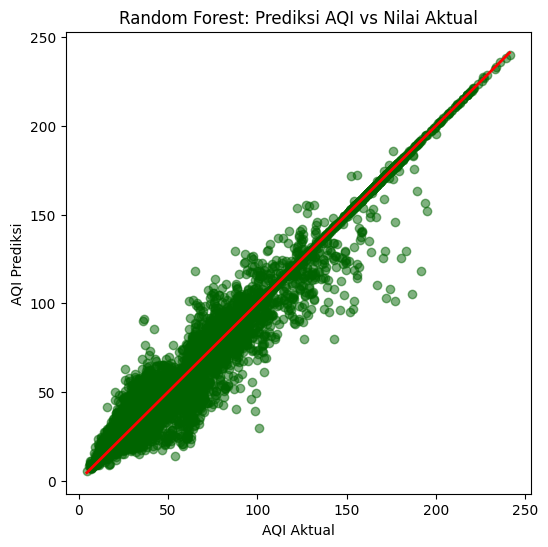

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print("🌳 Random Forest Results:")
print("Mean Absolute Error (MAE):", round(mae_rf, 2))
print("Mean Squared Error (MSE):", round(mse_rf, 2))
print("Root Mean Squared Error (RMSE):", round(rmse_rf, 2))
print("R² Score:", round(r2_rf, 3))

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_rf = cross_val_score(rf_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores:", [round(score, 3) for score in cv_scores_rf])
print("Mean CV R² Score:", round(cv_scores_rf.mean(), 3))
print("Std Dev CV R² Score:", round(cv_scores_rf.std(), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='darkgreen')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("Random Forest: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

* Decission Tree

🌲 Decision Tree Results:
Mean Absolute Error (MAE): 5.01
Mean Squared Error (MSE): 71.47
Root Mean Squared Error (RMSE): 8.45
R² Score: 0.946

Cross-validation R² Scores: [np.float64(0.946), np.float64(0.949), np.float64(0.951), np.float64(0.948), np.float64(0.948)]
Mean CV R² Score: 0.949
Std Dev CV R² Score: 0.002


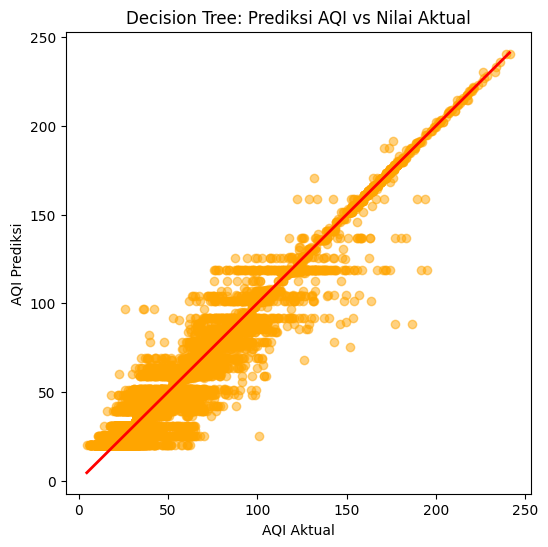

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

dt_model = DecisionTreeRegressor(random_state=42, max_depth=8)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)

print("🌲 Decision Tree Results:")
print("Mean Absolute Error (MAE):", round(mae_dt, 2))
print("Mean Squared Error (MSE):", round(mse_dt, 2))
print("Root Mean Squared Error (RMSE):", round(rmse_dt, 2))
print("R² Score:", round(r2_dt, 3))

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_dt = cross_val_score(dt_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores:", [round(score, 3) for score in cv_scores_dt])
print("Mean CV R² Score:", round(cv_scores_dt.mean(), 3))
print("Std Dev CV R² Score:", round(cv_scores_dt.std(), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_dt, alpha=0.5, color='orange')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("Decision Tree: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

* KNN

👥 K-Nearest Neighbors Results:
Mean Absolute Error (MAE): 3.86
Mean Squared Error (MSE): 57.41
Root Mean Squared Error (RMSE): 7.58
R² Score: 0.957

Cross-validation R² Scores: [np.float64(0.957), np.float64(0.959), np.float64(0.962), np.float64(0.958), np.float64(0.955)]
Mean CV R² Score: 0.958
Std Dev CV R² Score: 0.002


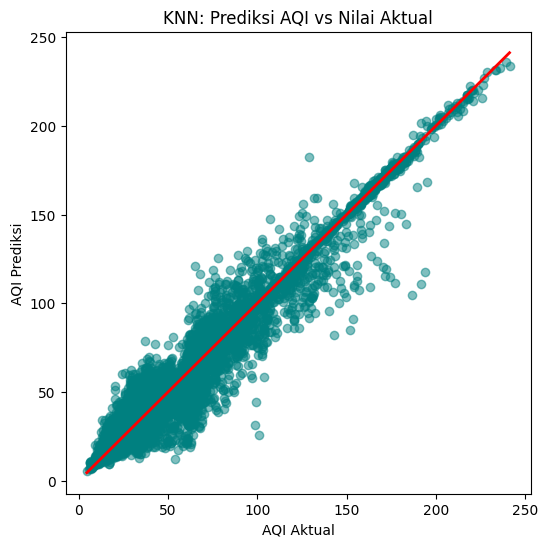

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)

print("👥 K-Nearest Neighbors Results:")
print("Mean Absolute Error (MAE):", round(mae_knn, 2))
print("Mean Squared Error (MSE):", round(mse_knn, 2))
print("Root Mean Squared Error (RMSE):", round(rmse_knn, 2))
print("R² Score:", round(r2_knn, 3))

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_knn = cross_val_score(knn_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores:", [round(score, 3) for score in cv_scores_knn])
print("Mean CV R² Score:", round(cv_scores_knn.mean(), 3))
print("Std Dev CV R² Score:", round(cv_scores_knn.std(), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_knn, alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("KNN: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

* XGBoost

🚀 XGBoost Results:
Mean Absolute Error (MAE): 4.02
Mean Squared Error (MSE): 56.44
Root Mean Squared Error (RMSE): 7.51
R² Score: 0.958

Cross-validation R² Scores: [np.float64(0.958), np.float64(0.961), np.float64(0.962), np.float64(0.96), np.float64(0.958)]
Mean CV R² Score: 0.96
Std Dev CV R² Score: 0.002


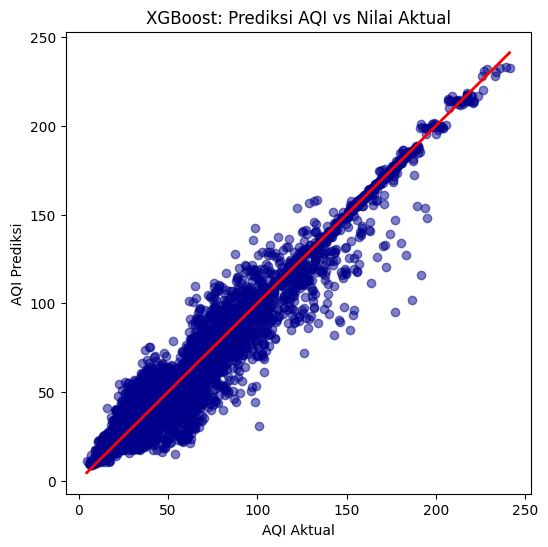

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)

print("🚀 XGBoost Results:")
print("Mean Absolute Error (MAE):", round(mae_xgb, 2))
print("Mean Squared Error (MSE):", round(mse_xgb, 2))
print("Root Mean Squared Error (RMSE):", round(rmse_xgb, 2))
print("R² Score:", round(r2_xgb, 3))

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_xgb = cross_val_score(xgb_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores:", [round(score, 3) for score in cv_scores_xgb])
print("Mean CV R² Score:", round(cv_scores_xgb.mean(), 3))
print("Std Dev CV R² Score:", round(cv_scores_xgb.std(), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5, color='darkblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("XGBoost: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

* Gradient Boosting

🚀 Gradient Boosting Regressor Results:
Mean Absolute Error (MAE): 4.61
Mean Squared Error (MSE): 67.66
Root Mean Squared Error (RMSE): 8.23
R² Score: 0.949

Cross-validation R² Scores (Gradient Boosting): [np.float64(0.949), np.float64(0.951), np.float64(0.954), np.float64(0.949), np.float64(0.949)]
Mean CV R² Score (Gradient Boosting): 0.95
Std Dev CV R² Score (Gradient Boosting): 0.002


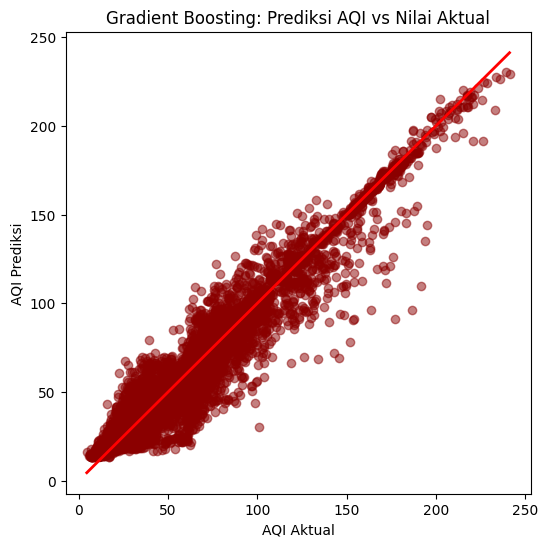

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

gbr_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gbr_model.fit(X_train, y_train)

y_pred_gbr = gbr_model.predict(X_test)

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)

print("🚀 Gradient Boosting Regressor Results:")
print("Mean Absolute Error (MAE):", round(mae_gbr, 2))
print("Mean Squared Error (MSE):", round(mse_gbr, 2))
print("Root Mean Squared Error (RMSE):", round(rmse_gbr, 2))
print("R² Score:", round(r2_gbr, 3))

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_gbr = cross_val_score(gbr_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores (Gradient Boosting):", [round(score, 3) for score in cv_scores_gbr])
print("Mean CV R² Score (Gradient Boosting):", round(cv_scores_gbr.mean(), 3))
print("Std Dev CV R² Score (Gradient Boosting):", round(np.std(cv_scores_gbr), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_gbr, alpha=0.5, color='darkred')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("Gradient Boosting: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

* LightBGM

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002974 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 60019, number of used features: 5
[LightGBM] [Info] Start training from score 50.239324
💡 LightGBM Results:
Mean Absolute Error (MAE): 4.11
Mean Squared Error (MSE): 57.0
Root Mean Squared Error (RMSE): 7.55
R² Score: 0.957
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 60019, number of used features: 5
[LightGBM] [Info] Start training from score 50.239324
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003186 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] 

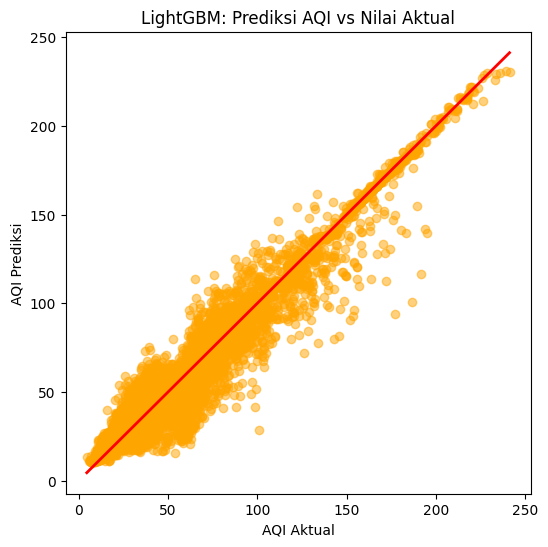

In [ ]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

lgbm_model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
lgbm_model.fit(X_train, y_train)

y_pred_lgbm = lgbm_model.predict(X_test)

mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
r2_lgbm = r2_score(y_test, y_pred_lgbm)
mse_lgbm = mean_squared_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mse_lgbm)

print("💡 LightGBM Results:")
print("Mean Absolute Error (MAE):", round(mae_lgbm, 2))
print("Mean Squared Error (MSE):", round(mse_lgbm, 2))
print("Root Mean Squared Error (RMSE):", round(rmse_lgbm, 2))
print("R² Score:", round(r2_lgbm, 3))

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lgbm = cross_val_score(lgbm_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores:", [round(score, 3) for score in cv_scores_lgbm])
print("Mean CV R² Score:", round(cv_scores_lgbm.mean(), 3))
print("Std Dev CV R² Score:", round(np.std(cv_scores_lgbm), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lgbm, alpha=0.5, color='orange')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("LightGBM: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

 * Ridge Regression

🏔️ Ridge Regression Results:
Mean Absolute Error (MAE): 7.0
Mean Squared Error (MSE): 118.95
Root Mean Squared Error (RMSE): 10.91
R² Score: 0.911

Cross-validation R² Scores (Ridge): [np.float64(0.911), np.float64(0.914), np.float64(0.918), np.float64(0.912), np.float64(0.913)]
Mean CV R² Score (Ridge): 0.913
Std Dev CV R² Score (Ridge): 0.002


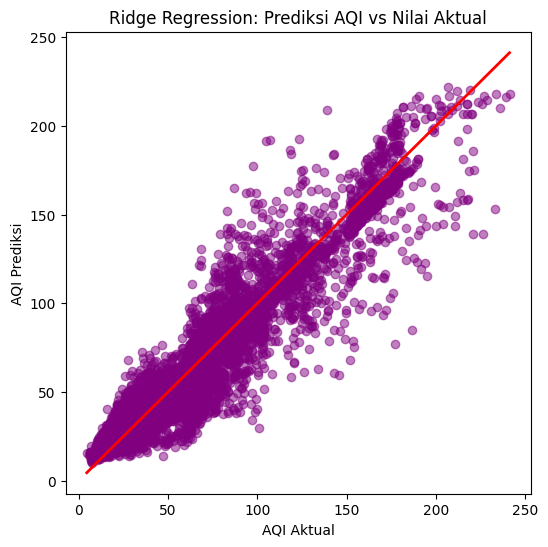

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)

print("🏔️ Ridge Regression Results:")
print("Mean Absolute Error (MAE):", round(mae_ridge, 2))
print("Mean Squared Error (MSE):", round(mse_ridge, 2))
print("Root Mean Squared Error (RMSE):", round(rmse_ridge, 2))
print("R² Score:", round(r2_ridge, 3))

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_ridge = cross_val_score(ridge_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores (Ridge):", [round(score, 3) for score in cv_scores_ridge])
print("Mean CV R² Score (Ridge):", round(cv_scores_ridge.mean(), 3))
print("Std Dev CV R² Score (Ridge):", round(cv_scores_ridge.std(), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_ridge, alpha=0.5, color='purple')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("Ridge Regression: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

* Lasso Regression


🪢 Lasso Regression Results:
Mean Absolute Error (MAE): 7.0
Mean Squared Error (MSE): 118.95
Root Mean Squared Error (RMSE): 10.91
R² Score: 0.911

Cross-validation R² Scores (Lasso): [np.float64(0.911), np.float64(0.914), np.float64(0.918), np.float64(0.912), np.float64(0.913)]
Mean CV R² Score (Lasso): 0.913
Std Dev CV R² Score (Lasso): 0.002


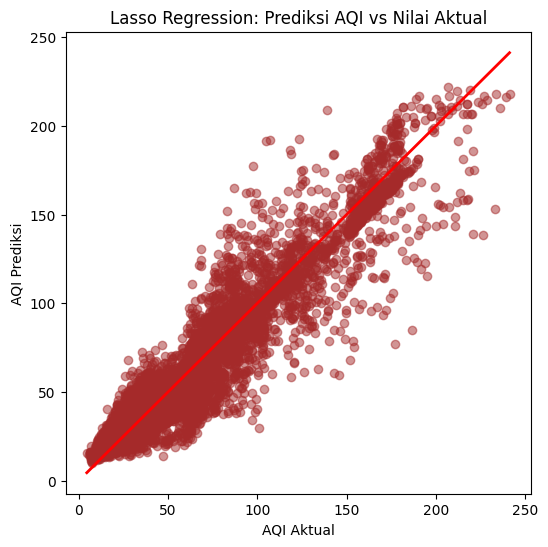

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

lasso_model = Lasso(alpha=0.1, random_state=42)
lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)

print("\n🪢 Lasso Regression Results:")
print("Mean Absolute Error (MAE):", round(mae_lasso, 2))
print("Mean Squared Error (MSE):", round(mse_lasso, 2))
print("Root Mean Squared Error (RMSE):", round(rmse_lasso, 2))
print("R² Score:", round(r2_lasso, 3))

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lasso = cross_val_score(lasso_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores (Lasso):", [round(score, 3) for score in cv_scores_lasso])
print("Mean CV R² Score (Lasso):", round(cv_scores_lasso.mean(), 3))
print("Std Dev CV R² Score (Lasso):", round(cv_scores_lasso.std(), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lasso, alpha=0.5, color='brown')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("Lasso Regression: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

,Model,MAE,MSE,RMSE,R² Score
1,Random Forest,3.610038,52.026934,7.212970,0.961023
3,KNN,3.856276,57.413329,7.577158,0.956988
4,XGBoost,4.020188,56.438494,7.512556,0.957718
5,LightGBM,4.106708,56.996315,7.549590,0.957300
8,Gradient Boosting Regressor,4.608873,67.658157,8.225458,0.949313
2,Decision Tree,5.007447,71.467854,8.453866,0.946459
0,Linear Regression,6.998160,118.950854,10.906459,0.910886
6,Ridge Regression,6.998160,118.950853,10.906459,0.910886
7,Lasso Regression,6.999153,118.948328,10.906343,0.910888


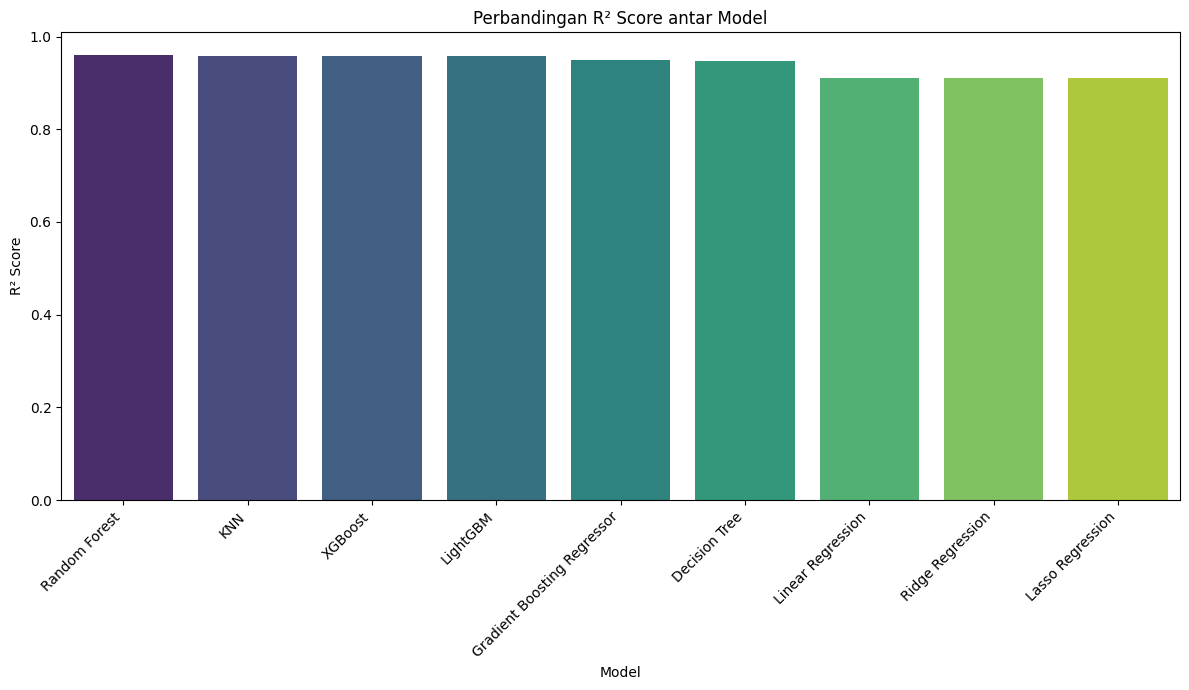

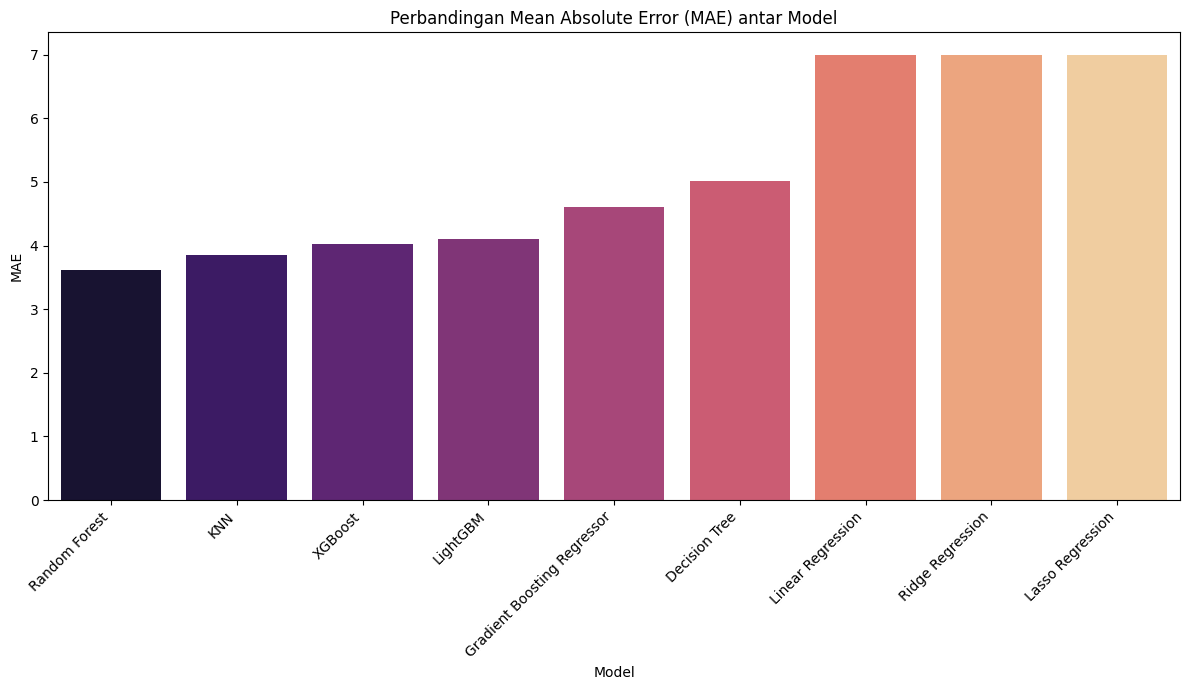

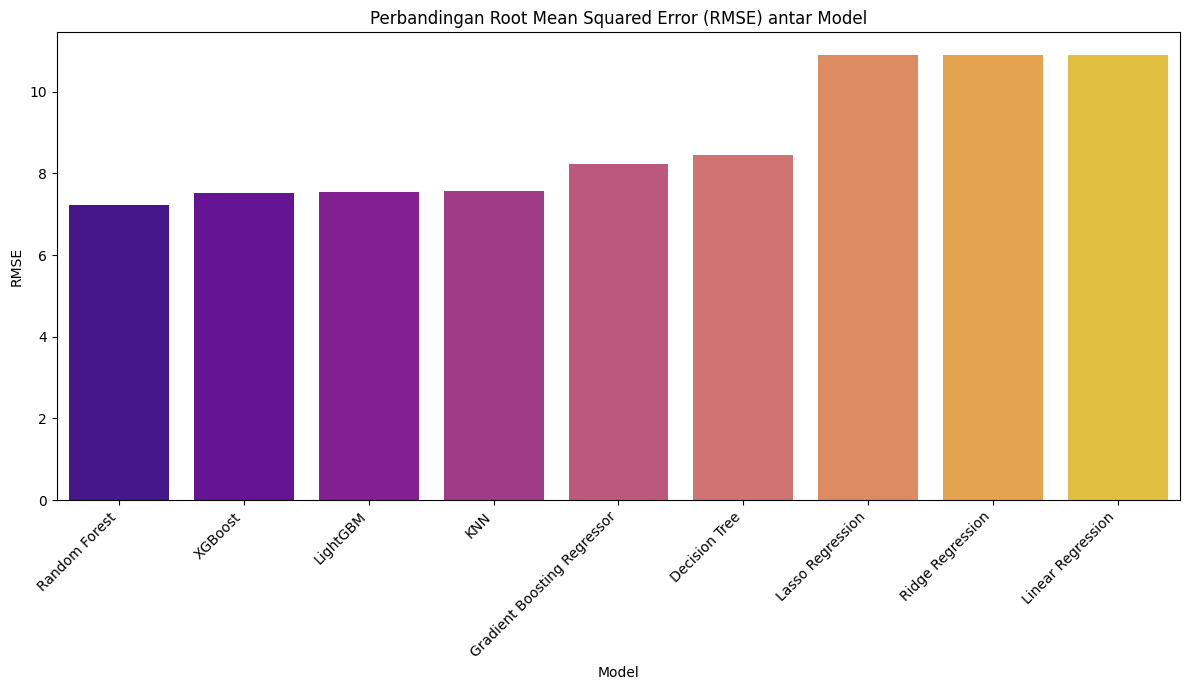

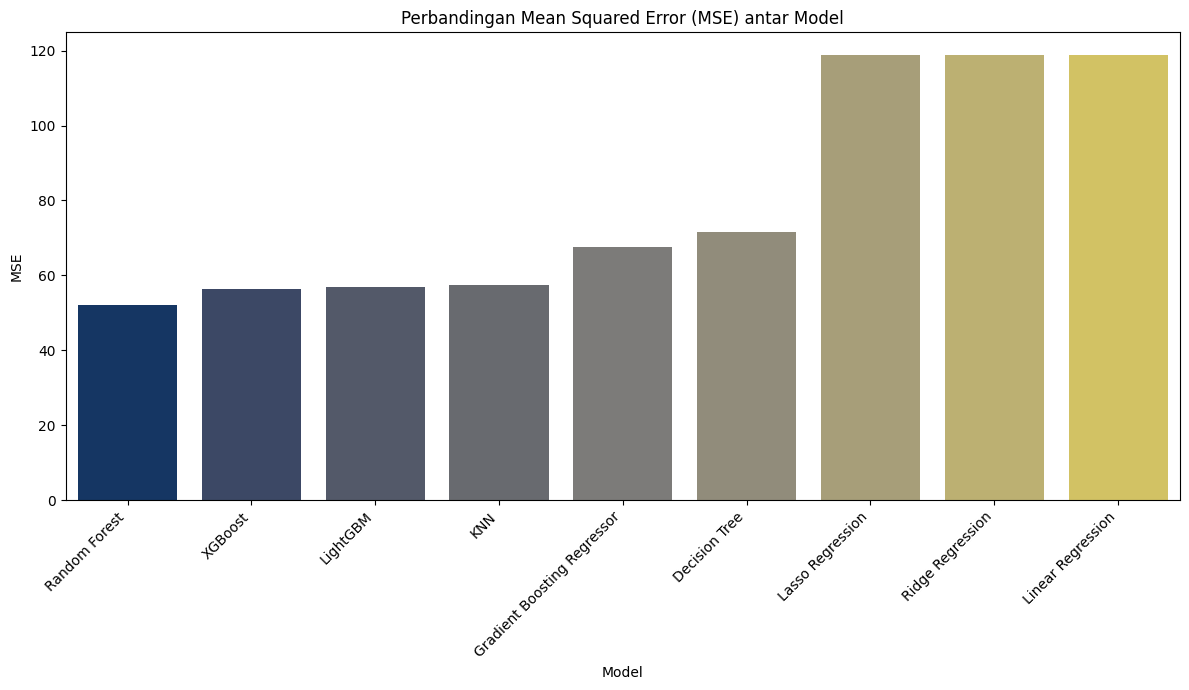

In [ ]:
models = [
    'Linear Regression',
    'Random Forest',
    'Decision Tree',
    'KNN',
    'XGBoost',
    'LightGBM',
    'Ridge Regression',
    'Lasso Regression',
    'Gradient Boosting Regressor'
]
mae_scores = [
    mae_lr,
    mae_rf,
    mae_dt,
    mae_knn,
    mae_xgb,
    mae_lgbm,
    mae_ridge,
    mae_lasso,
    mae_gbr
]
r2_scores = [
    r2_lr,
    r2_rf,
    r2_dt,
    r2_knn,
    r2_xgb,
    r2_lgbm,
    r2_ridge,
    r2_lasso,
    r2_gbr
]
mse_scores = [
    mse_lr,
    mse_rf,
    mse_dt,
    mse_knn,
    mse_xgb,
    mse_lgbm,
    mse_ridge,
    mse_lasso,
    mse_gbr
]
rmse_scores = [
    rmse_lr,
    rmse_rf,
    rmse_dt,
    rmse_knn,
    rmse_xgb,
    rmse_lgbm,
    rmse_ridge,
    rmse_lasso,
    rmse_gbr
]

results_df = pd.DataFrame({
    'Model': models,
    'MAE': mae_scores,
    'MSE': mse_scores,
    'RMSE': rmse_scores,
    'R² Score': r2_scores
}).sort_values(by='MAE')

display(results_df)

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='R² Score', data=results_df, palette='viridis', hue='Model', legend=False)
plt.title('Perbandingan R² Score antar Model')
plt.xticks(rotation=45, ha='right')
plt.ylabel('R² Score')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='MAE', data=results_df.sort_values(by='MAE', ascending=True), palette='magma', hue='Model', legend=False)
plt.title('Perbandingan Mean Absolute Error (MAE) antar Model')
plt.xticks(rotation=45, ha='right')
plt.ylabel('MAE')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='RMSE', data=results_df.sort_values(by='RMSE', ascending=True), palette='plasma', hue='Model', legend=False)
plt.title('Perbandingan Root Mean Squared Error (RMSE) antar Model')
plt.xticks(rotation=45, ha='right')
plt.ylabel('RMSE')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='MSE', data=results_df.sort_values(by='MSE', ascending=True), palette='cividis', hue='Model', legend=False)
plt.title('Perbandingan Mean Squared Error (MSE) antar Model')
plt.xticks(rotation=45, ha='right')
plt.ylabel('MSE')
plt.tight_layout()
plt.show()


# Pengujian Model

## Menyimpan Model Terbaik

In [ ]:
import joblib

joblib.dump(rf_model, "best_model_random_forest.joblib")

print("✅ Model Random Forest terbaik berhasil disimpan sebagai best_model_random_forest.joblib")

✅ Model Random Forest terbaik berhasil disimpan sebagai best_model_random_forest.joblib


## Uji Model

* Input User

In [ ]:
import joblib
import pandas as pd

# Memuat model terbaik
loaded_model = joblib.load('best_model_random_forest.joblib')

print("Masukkan nilai untuk fitur-fitur berikut untuk memprediksi AQI:")

# Meminta input dari pengguna
try:
    no2 = float(input("NO2: "))
    so2 = float(input("SO2: "))
    o3 = float(input("O3: "))
    pm2_5 = float(input("PM2.5: "))
    pm10 = float(input("PM10: "))

    user_input = pd.DataFrame([{
        'NO2': no2,
        'SO2': so2,
        'O3': o3,
        'PM2.5': pm2_5,
        'PM10': pm10
    }])

    # Memprediksi AQI
    predicted_aqi = loaded_model.predict(user_input)[0]

    aqi_category = ""
    if 0 <= predicted_aqi <= 50:
        aqi_category = "Good"
    elif 51 <= predicted_aqi <= 100:
        aqi_category = "Moderate"
    elif 101 <= predicted_aqi <= 150:
        aqi_category = "Unhealthy for Sensitive Groups"
    elif 151 <= predicted_aqi <= 200:
        aqi_category = "Unhealthy"
    elif 201 <= predicted_aqi <= 300:
        aqi_category = "Very Unhealthy"
    elif 301 <= predicted_aqi <= 500:
        aqi_category = "Hazardous"
    else:
        aqi_category = "Beyond AQI Scale"

    print(f"\nPrediksi AQI: {predicted_aqi:.2f}\nkategori: {aqi_category}")
except ValueError:
    print("Input tidak valid. Harap masukkan angka untuk setiap fitur.")


Masukkan nilai untuk fitur-fitur berikut untuk memprediksi AQI:
NO2: 1
SO2: 1
O3: 1
PM2.5: 1
PM10: 1

Prediksi AQI: 9.68
kategori: Good


* Realtime

In [ ]:
import requests
import time
import pandas as pd
import joblib

loaded_rf_model = None
try:
    loaded_rf_model = joblib.load("best_model_random_forest.joblib")
    print("Model berhasil dimuat.")
except FileNotFoundError:
    print("Error: File best_model_random_forest.joblib tidak ditemukan. Klasifikasi tidak dapat dilakukan.")


latitude = -6.9222
longitude = 107.6069

API_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"

# Parameter permintaan data
# Memastikan semua polutan yang diperlukan model ada
params = {
    'latitude': latitude,
    'longitude': longitude,
    'current': 'pm2_5,nitrogen_dioxide,ozone,pm10,sulphur_dioxide',
    'timezone': 'Asia/Bangkok'
}

print(f"Memulai pengambilan data kualitas udara terkini untuk Bandung ({latitude}, {longitude}) dari OpenMeteo dan klasifikasi...")

start_time = time.time()
duration = 10
interval = 1

while time.time() - start_time < duration:
    try:
        response = requests.get(API_URL, params=params)
        response.raise_for_status()

        data = response.json()

        if 'current' in data:
            current_data = data['current']
            print(f"\n--- Data Terkini ({time.strftime('%H:%M:%S')}) ---")
            print(f"  PM2.5: {current_data.get('pm2_5')} {data['current_units'].get('pm2_5')}")
            print(f"  NO2: {current_data.get('nitrogen_dioxide')} {data['current_units'].get('nitrogen_dioxide')}")
            print(f"  Ozone: {current_data.get('ozone')} {data['current_units'].get('ozone')}")
            print(f"  PM10: {current_data.get('pm10')} {data['current_units'].get('pm10')}")
            print(f"  SO2: {current_data.get('sulphur_dioxide')} {data['current_units'].get('sulphur_dioxide')}")

            if loaded_rf_model is not None:
                try:
                    no2_val = current_data.get('nitrogen_dioxide', 0)
                    so2_val = current_data.get('sulphur_dioxide', 0)
                    o3_val = current_data.get('ozone', 0)
                    pm25_val = current_data.get('pm2_5', 0)
                    pm10_val = current_data.get('pm10', 0)

                    input_for_model = pd.DataFrame([[
                        no2_val,
                        so2_val,
                        o3_val,
                        pm25_val,
                        pm10_val
                    ]], columns=['NO2', 'SO2', 'O3', 'PM2.5', 'PM10'])

                    predicted_aqi = loaded_rf_model.predict(input_for_model)[0]

                    aqi_category = ""
                    if 0 <= predicted_aqi <= 50:
                        aqi_category = 'Good'
                    elif 51 <= predicted_aqi <= 100:
                        aqi_category = 'Moderate'
                    elif 101 <= predicted_aqi <= 150:
                        aqi_category = 'Unhealthy for Sensitive Groups'
                    elif 151 <= predicted_aqi <= 200:
                        aqi_category = 'Unhealthy'
                    elif 201 <= predicted_aqi <= 300:
                        aqi_category = 'Very Unhealthy'
                    else:
                        aqi_category = 'Hazardous'

                    print(f"  Prediksi AQI Model: {predicted_aqi:.2f}")
                    print(f"  Kategori AQI Prediksi: {aqi_category}")

                except Exception as e:
                    print(f"Error saat memproses data atau prediksi dengan model: {e}")
            else:
                 print("\nModel Random Forest belum dimuat. Tidak dapat melakukan prediksi.")

        else:
            print(f"\n--- Data Terkini ({time.strftime('%H:%M:%S')}) ---")
            print("Data 'current' tidak ditemukan dalam respons API.")
            print("Respons API lengkap:", data)


    except requests.exceptions.RequestException as e:
        print(f"\nError mengambil data dari OpenMeteo API: {e}")
    except Exception as e:
        print(f"\nError tidak terduga: {e}")

    if time.time() - start_time < duration:
        time.sleep(interval)

print("\nSimulasi pengambilan data dan klasifikasi selesai.")


Model berhasil dimuat.
Memulai pengambilan data kualitas udara terkini untuk Bandung (-6.9222, 107.6069) dari OpenMeteo dan klasifikasi...

--- Data Terkini (12:42:17) ---
  PM2.5: 82.7 μg/m³
  NO2: 80.8 μg/m³
  Ozone: 6.0 μg/m³
  PM10: 83.1 μg/m³
  SO2: 37.1 μg/m³
  Prediksi AQI Model: 81.41
  Kategori AQI Prediksi: Moderate

--- Data Terkini (12:42:18) ---
  PM2.5: 82.7 μg/m³
  NO2: 80.8 μg/m³
  Ozone: 6.0 μg/m³
  PM10: 83.1 μg/m³
  SO2: 37.1 μg/m³
  Prediksi AQI Model: 81.41
  Kategori AQI Prediksi: Moderate

--- Data Terkini (12:42:20) ---
  PM2.5: 82.7 μg/m³
  NO2: 80.8 μg/m³
  Ozone: 6.0 μg/m³
  PM10: 83.1 μg/m³
  SO2: 37.1 μg/m³
  Prediksi AQI Model: 81.41
  Kategori AQI Prediksi: Moderate

--- Data Terkini (12:42:22) ---
  PM2.5: 82.7 μg/m³
  NO2: 80.8 μg/m³
  Ozone: 6.0 μg/m³
  PM10: 83.1 μg/m³
  SO2: 37.1 μg/m³
  Prediksi AQI Model: 81.41
  Kategori AQI Prediksi: Moderate

--- Data Terkini (12:42:23) ---
  PM2.5: 82.7 μg/m³
  NO2: 80.8 μg/m³
  Ozone: 6.0 μg/m³
  PM10: 83.1 μg

# Task
Convert the 'Date' column in `df_q5` to datetime objects using `pd.to_datetime()` before accessing `.dt` attributes.

## Convert 'Date' column to datetime

### Subtask:
Convert the 'Date' column in `df_q5` to datetime objects using `pd.to_datetime()` before accessing `.dt` attributes.


## Summary:

### Data Analysis Key Findings
*   The 'Date' column in the `df_q5` DataFrame was successfully converted to datetime objects, allowing for time-based data manipulations and analyses.

### Insights or Next Steps
*   This conversion enables the extraction of various date components (e.g., year, month, day, day of week) for further time-series analysis or feature engineering.
